# 2-1. 미니 프로젝트 : 가위바위보 분류기를 만들자

## 실험 정보
- 데이터
    - 훈련 데이터 :  웹캠을 통해 직접찍은 오른손 가위바위보 사진 300장
    - 테스트 데이터 : LMS 에서 제공한 사진 300장
    - 28X28로 resize, 이후 표준화 /225
- 실험 결과
    test_loss: 1.991393804550171 
    test_accuracy: 0.49666666984558105

- 실험 샘플링을 통한 결과 분석
    - 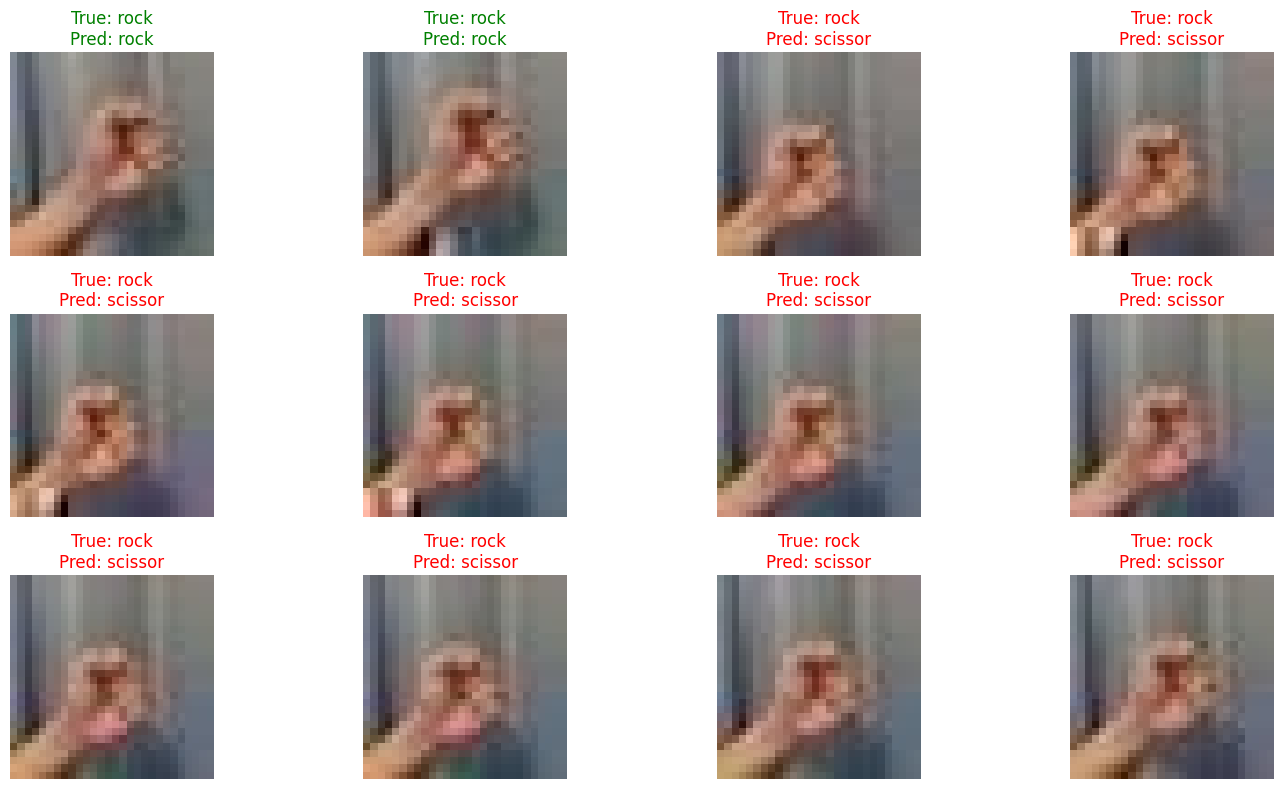

- 회고
    - 워낙 소규모 데이터셋이라서 `n_channel_1`, `n_channel_2` ,`n_dense`, `n_train_epoch`  값을 높이면 오히러 과적합 
    - epoch은 6~7회 넘어가면 `accuracy: 1.0000` 나와서 거의 정답을 외워서 맞추는 경향 있음, 
        - Dropout,  EarlyStopping 코드 추가하여 과적합 방지 
    - 같은 코드인데 수행할 때마다 결과가 다름
        -  랜덤 시드 함수 추가 

## 환경설정 및 라이브러리 버전 확인

In [25]:
import sys, typing_extensions
print(sys.executable)
print(typing_extensions.__file__)

d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Scripts\python.exe
d:\git\01_mdls_ds8_open\08_dl\260305_dl_mini-project_rock scissor paper\venv\Lib\site-packages\typing_extensions.py


In [26]:
# pip install "tensorflow>=2.12,<2.13" -> for 로컬 실행, 한번만 설치하면됨 

import os
import random
import tensorflow as tf
import numpy as np

print(tf.__version__)
print(np.__version__)

# LMS 버전 
# tensorflow 2.6.0
# numpy 1.22.2

# 랜덤시드 코드 추가 
# 재현성 확보 및 파라미터 영향 확인용 
def set_seed(seed: int = 42): 
    os.environ["PYTHONHASHSEED"] = str(seed) 
    random.seed(seed) # 표준 라이브러리 random 모듈의 난수 시퀀스 고정
    np.random.seed(seed) # NumPy 난수 발생기의 시드 고정
    tf.random.set_seed(seed) # TensorFlow 전역 난수 시드 고정
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass
set_seed(42) # 전체 코드 실행 전역에 시드 42 적용

2.12.1
1.24.3


## 데이터 준비
- 구글 teachable machine 사이트 :"https://teachablemachine.withgoogle.com/
- LMS aiffle 클라우드 제공 데이터셋 

## 데이터 불러오기 + Resize

In [27]:
from PIL import Image 
import glob
import os

print("PIL 라이브러리 import 완료!")

PIL 라이브러리 import 완료!


In [28]:
def resize_images(img_path):
    images = glob.glob(img_path + "/*.jpg")  

    print(len(images), " images to be resized.")

    target_size = (28, 28)
    for img in images:
        old_img = Image.open(img)
        new_img = old_img.resize(target_size, Image.LANCZOS)
        new_img.save(img, "JPEG")

    print(len(images), " images resized.")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/scissor/"
resize_images(image_dir_path)
print("가위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/rock"
resize_images(image_dir_path)

print("바위 이미지 resize 완료!")

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/paper"
resize_images(image_dir_path)

print("보 이미지 resize 완료!")

100  images to be resized.
100  images resized.
가위 이미지 resize 완료!
100  images to be resized.
100  images resized.
바위 이미지 resize 완료!
100  images to be resized.
100  images resized.
보 이미지 resize 완료!


In [29]:
import numpy as np

def load_data(img_path, number_of_data=300):  # 가위바위보 이미지 개수 총합에 주의하세요.
    # 가위 : 0, 바위 : 1, 보 : 2
    img_size=28
    color=3
    #이미지 데이터와 라벨(가위 : 0, 바위 : 1, 보 : 2) 데이터를 담을 행렬(matrix) 영역을 생성합니다.
    imgs=np.zeros(number_of_data*img_size*img_size*color,dtype=np.int32).reshape(number_of_data,img_size,img_size,color)
    labels=np.zeros(number_of_data,dtype=np.int32)

    idx=0
    for file in glob.iglob(img_path+'/scissor/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=0   # 가위 : 0
        idx=idx+1

    for file in glob.iglob(img_path+'/rock/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=1   # 바위 : 1
        idx=idx+1  
    
    for file in glob.iglob(img_path+'/paper/*.jpg'):
        img = np.array(Image.open(file),dtype=np.int32)
        imgs[idx,:,:,:]=img    # 데이터 영역에 이미지 행렬을 복사
        labels[idx]=2   # 보 : 2
        idx=idx+1
        
    print("학습데이터(x_train)의 이미지 개수는", idx,"입니다.")
    return imgs, labels

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/rock_scissor_paper/"
(x_train, y_train)=load_data(image_dir_path)
x_train_norm = x_train/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_train shape: {}".format(x_train.shape))
print("y_train shape: {}".format(y_train.shape))

학습데이터(x_train)의 이미지 개수는 300 입니다.
x_train shape: (300, 28, 28, 3)
y_train shape: (300,)


라벨:  2


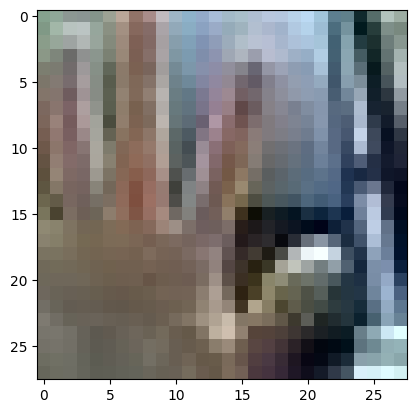

In [30]:
import matplotlib.pyplot as plt

plt.imshow(x_train[200])
print('라벨: ', y_train[200])

# 딥러닝 네트워크 설계하기|

In [31]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

# model 생성
# 합성곱 신경망(CNN) 하이퍼파라미터 설정
n_channel_1   = 16   # 첫 번째 합성곱 층에서 사용할 필터(채널) 개수
n_channel_2   = 64   # 두 번째 합성곱 층에서 사용할 필터(채널) 개수
n_dense       = 64   # 완전연결(Dense) 층의 뉴런 개수
n_train_epoch = 10   # 최대 학습 epoch 수(학습 반복 횟수의 상한, 실제 학습 시 사용 예정)

# 순차적(Sequential)으로 레이어를 쌓는 방식의 Keras 모델 생성
model=keras.models.Sequential()

# 1번째 합성곱 층 + 풀링 층(Max Pooling) 
model.add(keras.layers.Conv2D(n_channel_1, (3,3), activation='relu', input_shape=(28,28,3))) 
model.add(keras.layers.MaxPool2D(2,2)) 

# 2번째 합성곱 층 + 풀링 층(Max Pooling) 
model.add(keras.layers.Conv2D(n_channel_2, (3,3), activation='relu')) 
model.add(keras.layers.MaxPooling2D((2,2)))

model.add(keras.layers.Flatten()) # Flatten 층 2차원 형태의 특징맵을 1차원 벡터로 펼침
model.add(keras.layers.Dense(n_dense, activation='relu')) # 완전연결(Dense) 층

model.add(keras.layers.Dropout(0.3)) # 추가, 학습 중 매 스텝마다 뉴런 일부(30%)를 랜덤으로 꺼서, 특정 뉴런 조합에 과하게 의존하지 못하게 함 (과적합 방지)
model.add(keras.layers.Dense(3, activation='softmax')) # 출력(Dense) 층 
# 중간 Dense 층 = 은닉층, hidden layer
# 마지막 Dense 층 = 출력층, output layer

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 26, 26, 16)        448       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 13, 13, 16)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 11, 11, 64)        9280      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_2 (Flatten)         (None, 1600)              0         
                                                                 
 dense_4 (Dense)             (None, 64)               

In [32]:
# model 훈련
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


#  EarlyStopping 코드 추가
# 학습 도중 조건을 만족하면 조기 종료하는 콜백 객체 리스트 추가
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2, # 지표가 2 epoch 연속으로 더 좋아지지 않으면 학습을 멈춤
        restore_best_weights=True
    )
]

#[추가] model.fit 에서 validation_split=0.2 수행 전 로 셔플 하여 validation_split 데이터 편향방지 
idx = np.random.permutation(len(x_train_norm))
x_train_norm, y_train = x_train_norm[idx], y_train[idx]

model.fit(
    x_train_norm,         
    y_train,              
    epochs=20,            # epoch은 EarlyStopping으로 더 일찍 끝날 수 있음
    validation_split=0.2, # 학습 데이터의 20%를 자동으로 검증용(val)으로 분리해서 사용
    callbacks=callbacks,  # 위에서 정의한 EarlyStopping 콜백을 학습 과정에 적용
    shuffle=True          # 각 epoch마다 학습 데이터를 섞어서 순서에 따른 편향을 줄임
)


Epoch 1/20
8/8 [==============================] - 1s 30ms/step - loss: 1.0408 - accuracy: 0.5083 - val_loss: 0.9178 - val_accuracy: 0.9667
Epoch 2/20
8/8 [==============================] - 0s 12ms/step - loss: 0.7849 - accuracy: 0.7833 - val_loss: 0.5823 - val_accuracy: 0.8000
Epoch 3/20
8/8 [==============================] - 0s 13ms/step - loss: 0.5475 - accuracy: 0.8125 - val_loss: 0.3406 - val_accuracy: 0.9500


## test 데이터 셋으로 검증 

In [33]:
# x_test, y_test 만들기 위해 image_dir_path 에서 호출 
# test 데이터셋은 LMS클라우드 에서 제공한 데이터 사용 
image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/scissor"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/rock"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/paper"
resize_images(image_dir_path)

image_dir_path = r"d:/git/01_mdls_ds8_open/08_dl/260305_dl_mini-project_rock scissor paper/test/"
(x_test, y_test)=load_data(image_dir_path)
x_test_norm = x_test/255.0   # 입력은 0~1 사이의 값으로 정규화

print("x_test shape: {}".format(x_test.shape))
print("y_test shape: {}".format(y_test.shape))

100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
100  images to be resized.
100  images resized.
학습데이터(x_train)의 이미지 개수는 300 입니다.
x_test shape: (300, 28, 28, 3)
y_test shape: (300,)


In [34]:
# model 테스트
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test, verbose=2) # x_test_norm, 정규화된 데이터셋 사용
print("test_loss: {} ".format(test_loss))
print("test_accuracy: {}".format(test_accuracy))

10/10 - 0s - loss: 1.0812 - accuracy: 0.3900 - 51ms/epoch - 5ms/step
test_loss: 1.0812289714813232 
test_accuracy: 0.38999998569488525


10/10 [==============================] - 0s 3ms/step


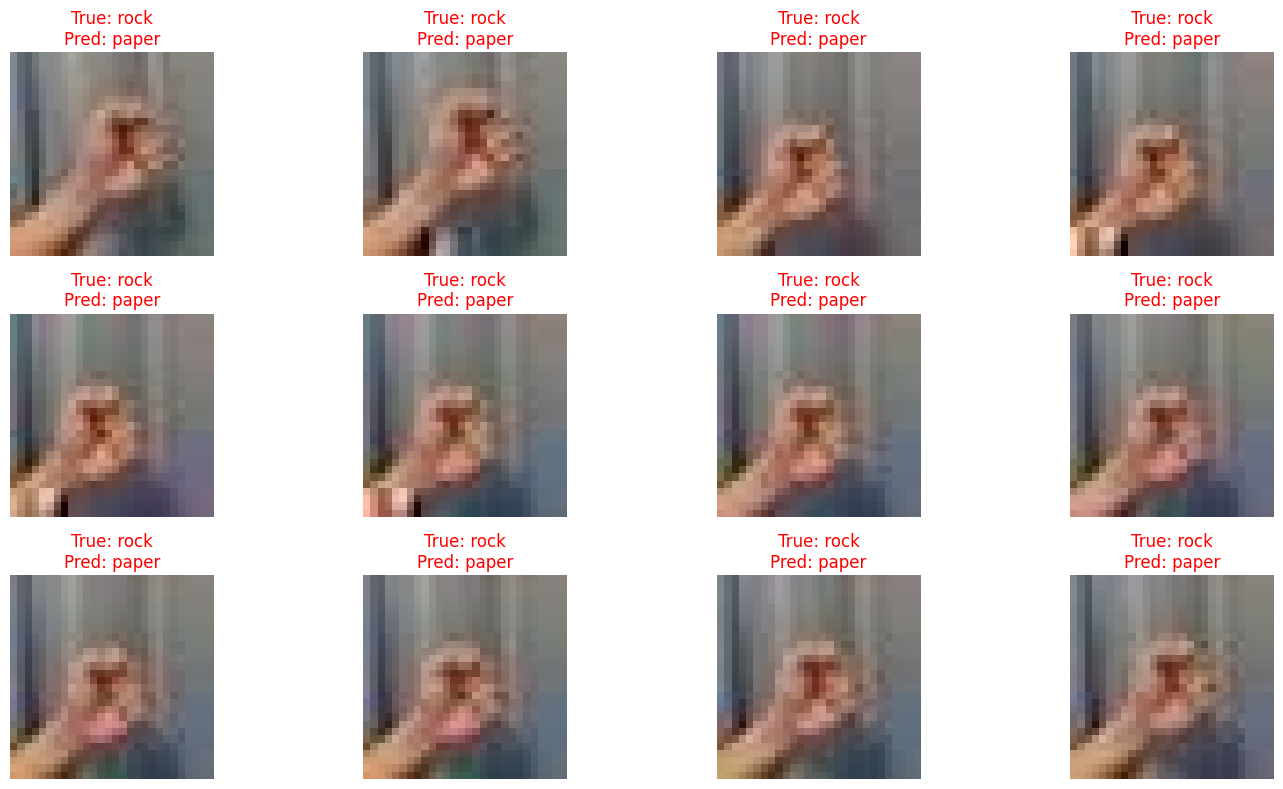

In [35]:
# [추가] 시각화 
import matplotlib.pyplot as plt

# 클래스 이름 매핑
class_names = ['scissor', 'rock', 'paper']   # 0, 1, 2

# 모델 예측
pred = model.predict(x_test_norm)          # (N, 3)
pred_label = np.argmax(pred, axis=1)  # 예측 라벨

# 원하는 만큼 출력
start_idx = 100
num_images = 12
plt.figure(figsize=(15, 8))

for i in range(num_images):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_test[start_idx+i])
    plt.axis('off')

    true_name = class_names[y_test[start_idx+i]]
    pred_name = class_names[pred_label[start_idx+i]]

    # 정답 / 예측 출력
    color = 'green' if y_test[start_idx+i] == pred_label[start_idx+i] else 'red'
    plt.title(f"True: {true_name}\nPred: {pred_name}", color=color)

plt.tight_layout()
plt.show()